# Filtrant — CV Screening ML Pipeline

Ce notebook couvre tout le cycle ML :
1. Chargement et exploration des données
2. Feature engineering & analyse
3. Comparaison de modèles
4. Évaluation complète (AUC, matrice de confusion, feature importance)
5. Export du modèle final → `model.joblib`

**Pour réentraîner** : exporte les candidats depuis l'API (`GET /api/v1/candidates/export.csv`), labellise la colonne `recommendation`, puis relance toutes les cellules.

## 0 · Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
RANDOM_STATE = 42

# ── Colonnes features (doivent correspondre à features.py) ──────────────────
FEATURE_COLUMNS = [
    # Original
    "total_years_experience",
    "num_positions",
    "avg_tenure_months",
    "education_level_score",
    "total_skills_count",
    "has_certifications",
    "language_count",
    "section_completeness_score",
    # New
    "max_language_score",
    "has_senior_title",
    "career_gap_months",
    "latest_job_duration",
    "has_summary",
    "num_certifications",
    "parse_quality_score",
]

MODEL_PATH = "model.joblib"

print(f"Setup OK — {len(FEATURE_COLUMNS)} features")

Setup OK — 15 features


## 1 · Chargement des données

Change `DATA_PATH` selon ta source :
- `synthetic_train.csv` → données synthétiques (500 lignes, pour démarrer)
- `candidates_export.csv` → vraies données exportées depuis l'API

In [4]:
DATA_PATH = "candidates_export.csv" 

df = pd.read_csv(DATA_PATH )

# Validation rapide
missing_cols = [c for c in FEATURE_COLUMNS + ["recommendation"] if c not in df.columns]
if missing_cols:
    raise ValueError(f"Colonnes manquantes dans le CSV : {missing_cols}")

# Garder uniquement Invite / Reject (ignorer 'pending')
df = df[df["recommendation"].isin(["Invite", "Reject"])].copy()
df[FEATURE_COLUMNS] = df[FEATURE_COLUMNS].fillna(0)

print(f"Dataset chargé : {len(df)} lignes")
print(f"  Invite : {(df['recommendation'] == 'Invite').sum()}")
print(f"  Reject : {(df['recommendation'] == 'Reject').sum()}")

if len(df) < 50:
    print("\n Moins de 50 lignes — les résultats ne seront pas fiables.")
    print("   Exporte plus de CVs labellisés depuis le dashboard avant de réentraîner.")

df.head()

ValueError: Colonnes manquantes dans le CSV : ['max_language_score', 'has_senior_title', 'career_gap_months', 'latest_job_duration', 'has_summary', 'num_certifications', 'parse_quality_score']

## 2 · Exploration des données (EDA)

In [28]:
# ── Statistiques descriptives par classe ────────────────────────────────────
df.groupby("recommendation")[FEATURE_COLUMNS].mean().T.style.background_gradient(axis=1, cmap="RdYlGn")

recommendation,Invite,Reject
total_years_experience,3.080392,1.970541
num_positions,2.098039,1.837838
avg_tenure_months,13.160784,8.825000
education_level_score,3.568627,3.378378
total_skills_count,12.686275,12.581081
has_certifications,0.921569,0.777027
language_count,1.960784,1.810811
section_completeness_score,6.000000,6.000000


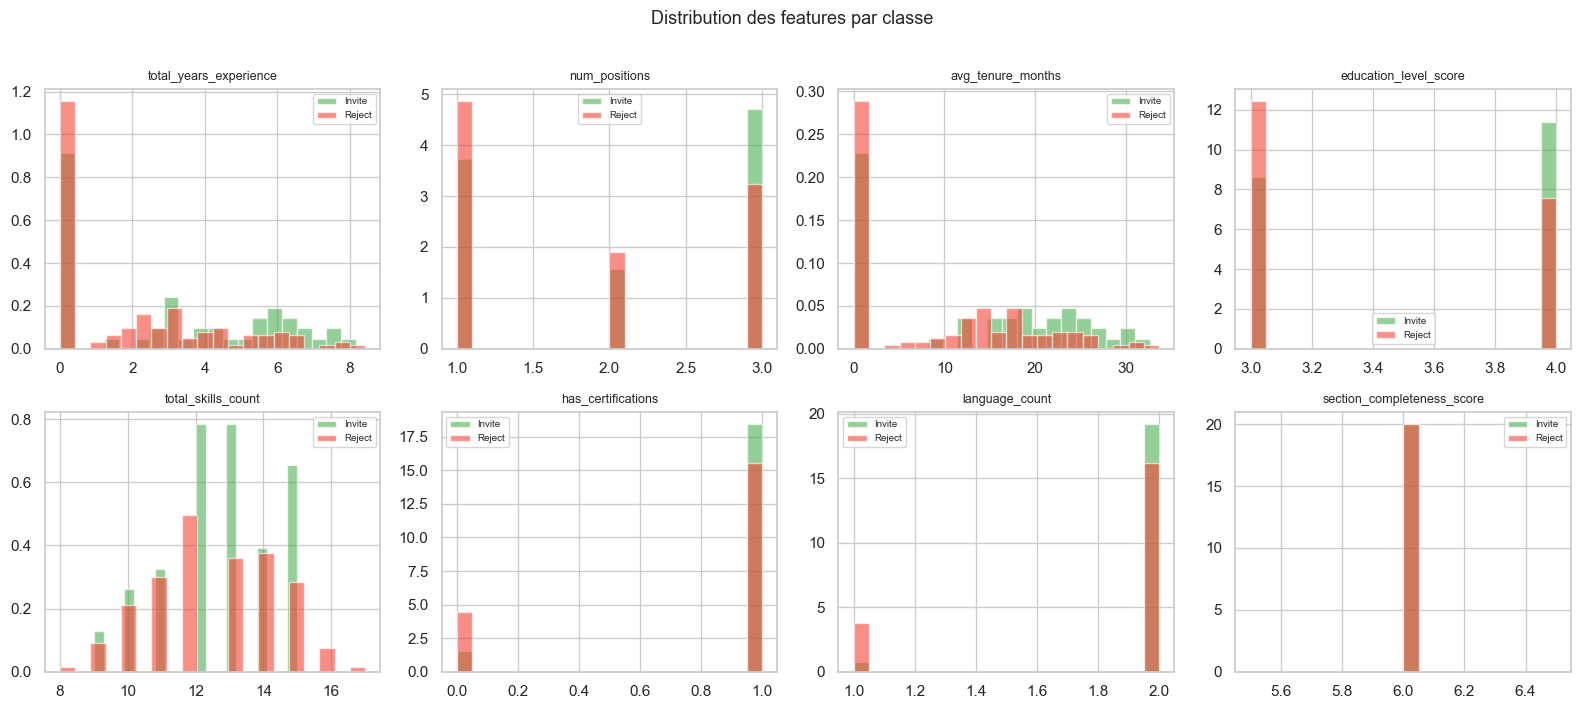

In [29]:
# ── Distribution de chaque feature par classe ───────────────────────────────
n = len(FEATURE_COLUMNS)
ncols = 4
nrows = (n + ncols - 1) // ncols  # ceil division

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLUMNS):
    for label, color in [("Invite", "#4CAF50"), ("Reject", "#F44336")]:
        axes[i].hist(
            df.loc[df["recommendation"] == label, col],
            bins=20, alpha=0.6, color=color, label=label, density=True
        )
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=7)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution des features par classe", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

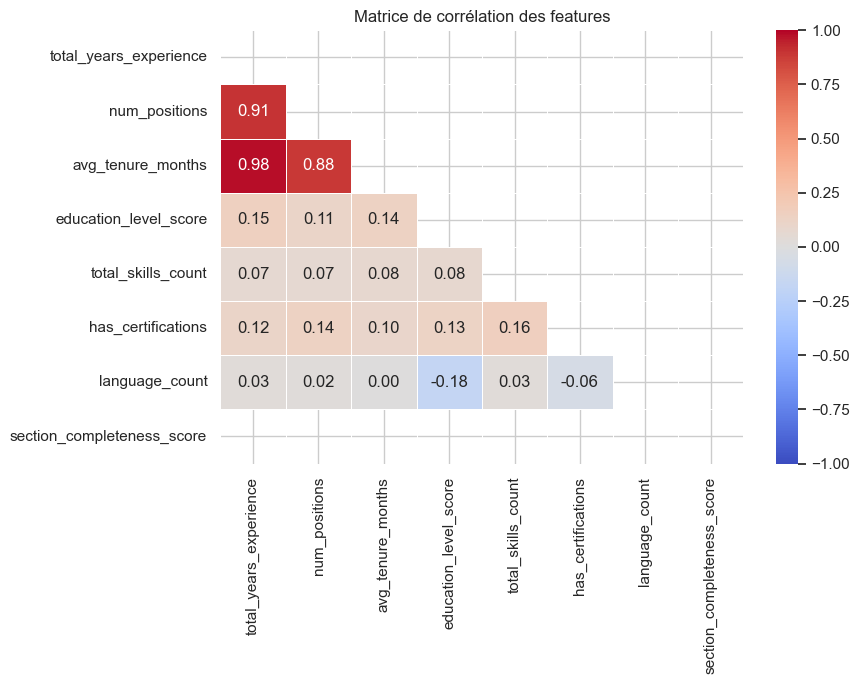

In [30]:
# ── Corrélation entre features ───────────────────────────────────────────────
plt.figure(figsize=(9, 7))
corr = df[FEATURE_COLUMNS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, linewidths=0.5)
plt.title("Matrice de corrélation des features")
plt.tight_layout()
plt.show()

## 3 · Préparation train / test

In [31]:
X = df[FEATURE_COLUMNS].values
y = (df["recommendation"] == "Invite").astype(int).values  # 0=Reject, 1=Invite

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train : {len(X_train)} lignes")
print(f"Test  : {len(X_test)} lignes")
print(f"Ratio Invite (train) : {y_train.mean():.1%}")
print(f"Ratio Invite (test)  : {y_test.mean():.1%}")

Train : 159 lignes
Test  : 40 lignes
Ratio Invite (train) : 25.8%
Ratio Invite (test)  : 25.0%


## 4 · Comparaison des modèles

In [32]:
CANDIDATES = {
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "RandomForest": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "GradientBoosting": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE)),
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

for name, pipeline in CANDIDATES.items():
    cv_f1 = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="f1").mean()
    pipeline.fit(X_train, y_train)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, y_proba)
    results.append({"Modèle": name, "CV F1 (train)": cv_f1, "AUC (test)": test_auc})
    print(f"{name:<22}  CV F1={cv_f1:.3f}  AUC={test_auc:.3f}")

results_df = pd.DataFrame(results).set_index("Modèle")
best_name = results_df["AUC (test)"].idxmax()
print(f"\n→ Meilleur modèle : {best_name} (AUC={results_df.loc[best_name, 'AUC (test)']:.3f})")

LogisticRegression      CV F1=0.542  AUC=0.578
RandomForest            CV F1=0.353  AUC=0.555
GradientBoosting        CV F1=0.430  AUC=0.562

→ Meilleur modèle : LogisticRegression (AUC=0.578)


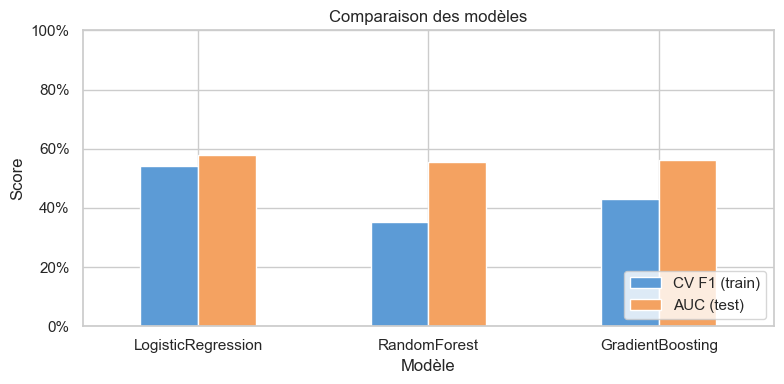

In [33]:
# ── Graphique comparaison ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
results_df.plot(kind="bar", ax=ax, color=["#5C9BD6", "#F4A261"])
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Comparaison des modèles")
ax.set_xticklabels(results_df.index, rotation=0)
ax.legend(loc="lower right")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

## 5 · Évaluation détaillée du meilleur modèle

In [34]:
best_pipeline = CANDIDATES[best_name]
y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

print(f"=== {best_name} — rapport de classification ===")
print(classification_report(y_test, y_pred, target_names=["Reject", "Invite"]))

=== LogisticRegression — rapport de classification ===
              precision    recall  f1-score   support

      Reject       0.80      0.53      0.64        30
      Invite       0.30      0.60      0.40        10

    accuracy                           0.55        40
   macro avg       0.55      0.57      0.52        40
weighted avg       0.68      0.55      0.58        40



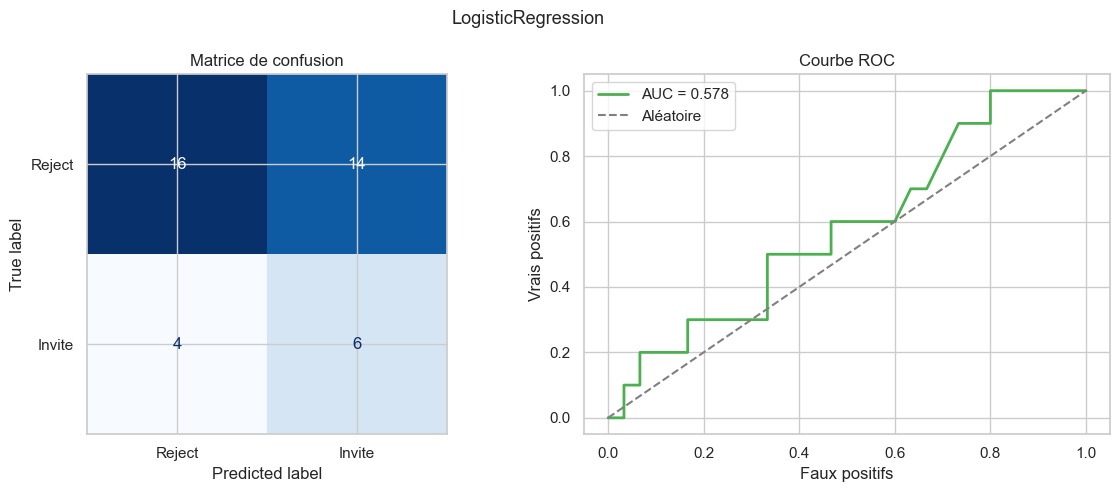

In [35]:
# ── Matrice de confusion + Courbe ROC ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["Reject", "Invite"]
).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matrice de confusion")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, color="#4CAF50", lw=2, label=f"AUC = {auc_score:.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="gray", label="Aléatoire")
axes[1].set_xlabel("Faux positifs")
axes[1].set_ylabel("Vrais positifs")
axes[1].set_title("Courbe ROC")
axes[1].legend()

plt.suptitle(f"{best_name}", fontsize=13)
plt.tight_layout()
plt.show()

## 6 · Feature importance

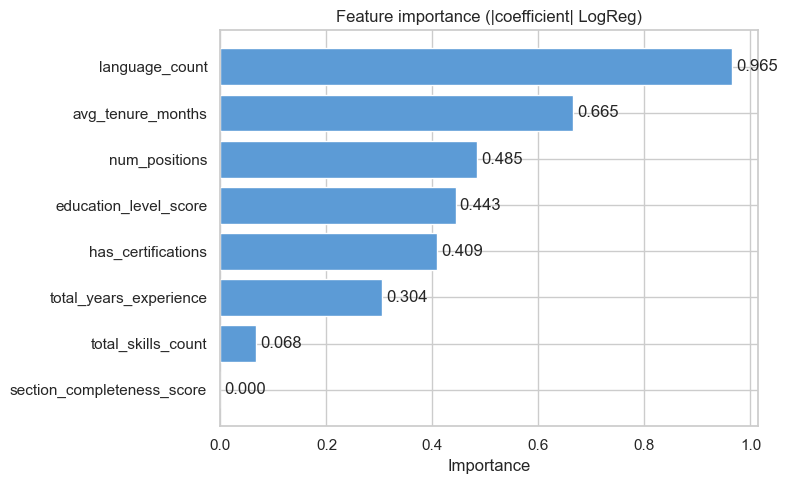

In [36]:
clf = best_pipeline.named_steps["clf"]

if hasattr(clf, "feature_importances_"):
    importances = clf.feature_importances_
    title = "Feature importance (gain)"
elif hasattr(clf, "coef_"):
    importances = np.abs(clf.coef_[0])
    title = "Feature importance (|coefficient| LogReg)"
else:
    importances = np.ones(len(FEATURE_COLUMNS))
    title = "Feature importance non disponible"

fi_df = pd.DataFrame({"feature": FEATURE_COLUMNS, "importance": importances})
fi_df = fi_df.sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(fi_df["feature"], fi_df["importance"], color="#5C9BD6")
ax.bar_label(bars, fmt="%.3f", padding=3)
ax.set_xlabel("Importance")
ax.set_title(title)
plt.tight_layout()
plt.show()

## 7 · Analyse de la distribution des scores de confiance

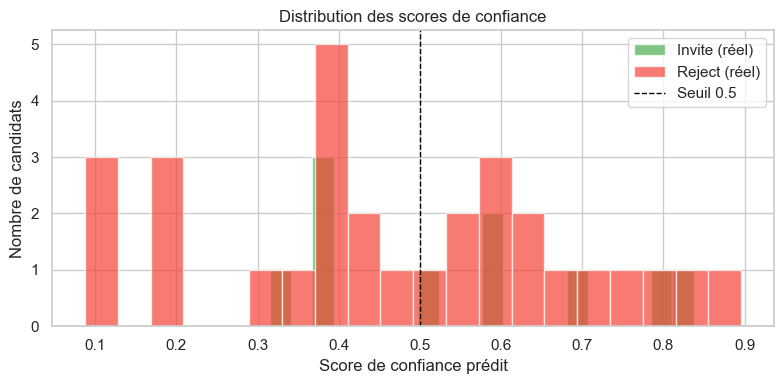

In [37]:
# Vérifie que le modèle est bien calibré : les scores de confiance doivent
# être étalés, pas tous collés à 0 ou 1.
probas_all = best_pipeline.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(probas_all[y_test == 1], bins=20, alpha=0.7, color="#4CAF50", label="Invite (réel)")
ax.hist(probas_all[y_test == 0], bins=20, alpha=0.7, color="#F44336", label="Reject (réel)")
ax.axvline(0.5, color="black", linestyle="--", linewidth=1, label="Seuil 0.5")
ax.set_xlabel("Score de confiance prédit")
ax.set_ylabel("Nombre de candidats")
ax.set_title("Distribution des scores de confiance")
ax.legend()
plt.tight_layout()
plt.show()

## 8 · Export du modèle final

On réentraîne sur **toutes les données** (train + test) avant de sauvegarder.

In [ ]:
# Réentraîner sur 100% des données
best_pipeline.fit(X, y)

# Sauvegarder
joblib.dump(best_pipeline, MODEL_PATH)
print(f"✓ Modèle sauvegardé : {MODEL_PATH}")
print(f"  Modèle : {best_name}")
print(f"  Features ({len(FEATURE_COLUMNS)}) : {FEATURE_COLUMNS}")
print(f"  Classes  : 0=Reject, 1=Invite")
print(f"  Entraîné sur : {len(X)} lignes")

# Vérification rapide — 15 valeurs dans l'ordre de FEATURE_COLUMNS:
# total_years, num_pos, avg_tenure, edu_score, skills, has_cert, lang_count, section_score,
# max_lang_score, has_senior, gap_months, latest_dur, has_summary, num_certs, parse_quality
test_input = np.array([[6.0, 3, 24.0, 4, 12, 1, 3, 6, 5, 1, 0, 18, 1, 2, 2]])
loaded = joblib.load(MODEL_PATH)
pred = loaded.predict(test_input)[0]
proba = loaded.predict_proba(test_input)[0].max()
print(f"\nTest rapide → {'Invite' if pred == 1 else 'Reject'} (confiance={proba:.2f})")

## 9 · Réentraîner sur données réelles

Une fois que tu as des CVs traités dans l'app :

```bash
# Exporte les candidats
curl http://localhost:8000/api/v1/candidates/export.csv -o ml/candidates_export.csv
```

Puis ouvre le CSV, vérifie/corrige la colonne `recommendation` (Invite ou Reject), change `DATA_PATH` en haut du notebook, et relance toutes les cellules.

Le nouveau `model.joblib` est chargé automatiquement par le backend au prochain appel de prédiction — **pas besoin de redémarrer Docker**.